In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [3]:
import insitupy
from insitupy._core.data import InSituData,ImageData, CACHE
from insitupy import InSituExperiment
from insitupy.io import read_xenium
import scanpy as sc
from pathlib import Path

### Load Xenium data into `InSituData` object

In [36]:
insitupy_project_downscaled = Path(CACHE / "out/demo_insitupy_project_downscaled")
xd = InSituData.read(insitupy_project_downscaled)
xd.load_all(skip="transcripts")
xd

/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		/Users/birthi/.cache/InSituPy/out/demo_insitupy_project_downscaled

    ➤ images
       nuclei:	(5477, 7525)
       HER2:	(5477, 7525)
       HE:	(5477, 7525, 3)
       CD20:	(5477, 7525)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 157600 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'leiden_split', 'leiden_summ', 'cell_type_dc'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'dendrogram_leiden_summ', 'leiden', 'leiden_colors', 'leiden_split', 'leiden_split_colors', 'leiden_summ_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_u

### Create `InSituExperiment` from regions

In [37]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [38]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     0d9f358c  ++--+  0001879  Replicate 1        TMA         A-1
1     d2e2c808  ++--+  0001879  Replicate 1        TMA         A-2
2     066ebd95  ++--+  0001879  Replicate 1        TMA         A-3
3     ace01047  ++-++  0001879  Replicate 1        TMA         B-1
4     b44e6c85  ++-++  0001879  Replicate 1        TMA         B-2
5     a3c2e1ea  ++-++  0001879  Replicate 1        TMA         B-3

In [39]:
exp.data[0].cells['main'].matrix.obs['batch']= '97c409d3'
exp.data[1].cells['main'].matrix.obs['batch']= 'a6acfb73'
exp.data[2].cells['main'].matrix.obs['batch']= 'df87b9fb'

exp.data[3].cells['main'].matrix.obs['batch']= '5dad4cdd'
exp.data[4].cells['main'].matrix.obs['batch']= 'a8b24ec2'
exp.data[5].cells['main'].matrix.obs['batch']= 'b19ca2f2'

### Generating "fake column" for pseudobulk analysis

In [40]:
exp.data[0].cells['main'].matrix.obs['condition']= 'A'
exp.data[1].cells['main'].matrix.obs['condition']= 'A'
exp.data[2].cells['main'].matrix.obs['condition']= 'A'

exp.data[3].cells['main'].matrix.obs['condition']= 'B'
exp.data[4].cells['main'].matrix.obs['condition']= 'B'
exp.data[5].cells['main'].matrix.obs['condition']= 'B'

In [45]:
exp.data[0].cells['main'].matrix.obs

,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area,n_genes_by_counts,n_genes,leiden,leiden_split,leiden_summ,cell_type_dc,batch,condition
30,64,0,0,64.0,264.073750,12.734063,41,41,13,13,13,Macrophages,97c409d3,A
31,32,0,0,32.0,177.057656,11.469688,27,27,13,13,13,Macrophages,97c409d3,A
39,92,0,0,92.0,94.421719,28.945156,50,50,4,4,0,Breast cancer,97c409d3,A
42,33,0,0,33.0,54.910000,35.808906,28,28,13,13,13,Macrophages,97c409d3,A
43,92,0,0,92.0,223.252500,145.087031,57,57,13,13,13,Macrophages,97c409d3,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51231,258,0,0,258.0,137.184687,76.449531,60,60,4,4,0,Breast cancer,97c409d3,A
51232,118,0,0,118.0,99.479219,24.294063,73,73,15,15,15,T cells,97c409d3,A
51233,166,0,0,166.0,146.712656,30.164375,62,62,9,9,9,Fibroblasts,97c409d3,A
51234,71,0,0,71.0,89.138438,29.983750,43,43,10,10,10,Breast myoepithelial cells,97c409d3,A


### Generating pseudobulk without consideration of neighborhood

In [9]:
import decoupler as dc
from insitupy.tools import generate_pseudobulk

/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
pdata_without_neighborhood=generate_pseudobulk(exp=exp,cell_layer='main',raw_counts='counts',sample_col='batch',groups_col='cell_type_dc',calculate_neighbors=None)

In [50]:
pdata_without_neighborhood

AnnData object with n_obs × n_vars = 50 × 297
    obs: 'batch', 'cell_type_dc', 'condition', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [51]:
pdata_without_neighborhood.obs

,batch,cell_type_dc,condition,psbulk_cells,psbulk_counts
97c409d3_B cells,97c409d3,B cells,A,88.0,12365.0
97c409d3_Breast cancer,97c409d3,Breast cancer,A,3357.0,725515.0
97c409d3_Breast glandular cells,97c409d3,Breast glandular cells,A,8.0,692.0
97c409d3_Breast myoepithelial cells,97c409d3,Breast myoepithelial cells,A,214.0,30750.0
97c409d3_Endothelial cells,97c409d3,Endothelial cells,A,249.0,35514.0
97c409d3_Fibroblasts,97c409d3,Fibroblasts,A,232.0,37374.0
97c409d3_Macrophages,97c409d3,Macrophages,A,451.0,53034.0
97c409d3_Mast cells,97c409d3,Mast cells,A,2.0,272.0
97c409d3_T cells,97c409d3,T cells,A,277.0,33516.0
a6acfb73_B cells,a6acfb73,B cells,A,28.0,6386.0


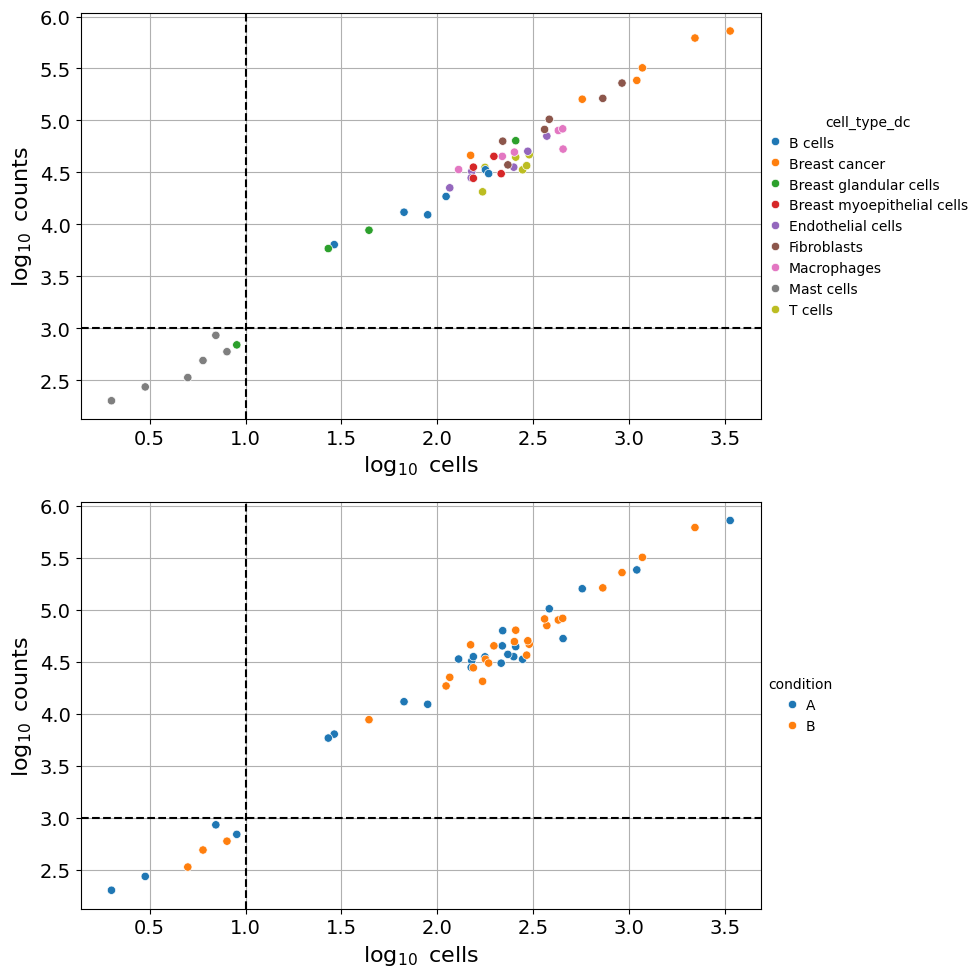

In [52]:
dc.pl.filter_samples(
    adata=pdata_without_neighborhood,
    groupby=["cell_type_dc","condition"],
    min_cells=10,
    min_counts=1000,
    figsize=(10, 10),
)

In [53]:
dc.pp.filter_samples(pdata_without_neighborhood, min_cells=10, min_counts=1000)

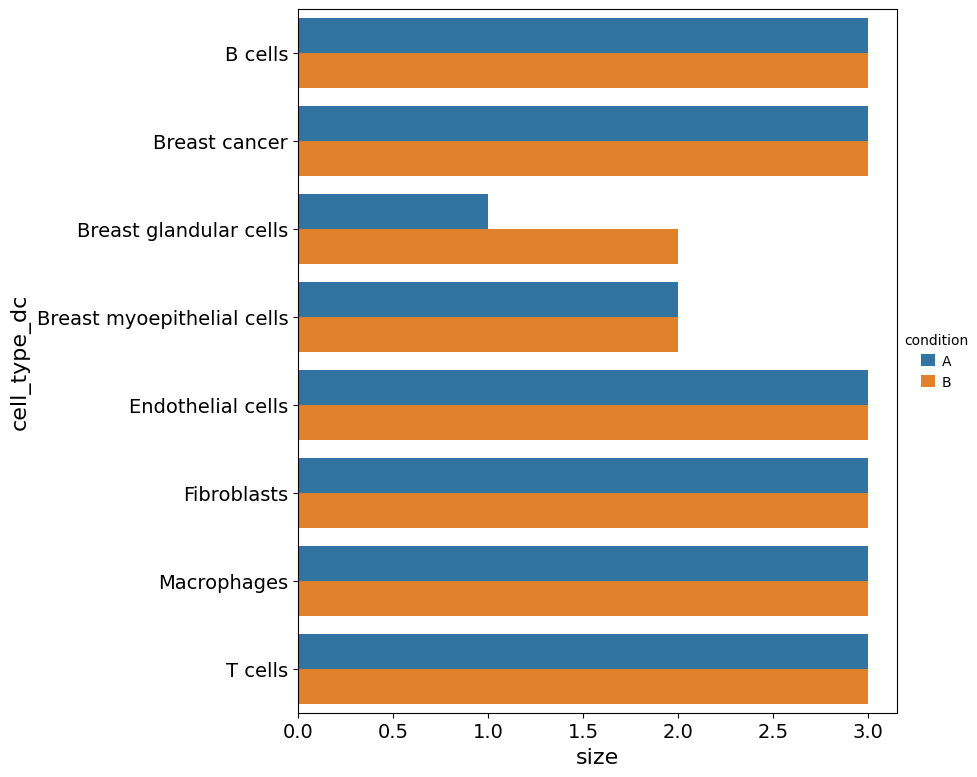

In [55]:
dc.pl.obsbar(adata=pdata_without_neighborhood, y="cell_type_dc", hue="condition", figsize=(10, 8))

In [56]:
# Store raw counts in layers
pdata_without_neighborhood.layers["counts"] = pdata_without_neighborhood.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata_without_neighborhood, target_sum=1e4)
sc.pp.log1p(pdata_without_neighborhood)
sc.pp.scale(pdata_without_neighborhood, max_value=10)
sc.tl.pca(pdata_without_neighborhood)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata_without_neighborhood, key="counts", inplace=True)

In [57]:
pdata_without_neighborhood

AnnData object with n_obs × n_vars = 43 × 297
    obs: 'batch', 'cell_type_dc', 'condition', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

In [58]:
pdata_without_neighborhood.obs.keys()


Index(['batch', 'cell_type_dc', 'condition', 'psbulk_cells', 'psbulk_counts'], dtype='object')

#### all columns in obs must have at least 2 different features

In [59]:
dc.tl.rankby_obsm(pdata_without_neighborhood, key="X_pca")

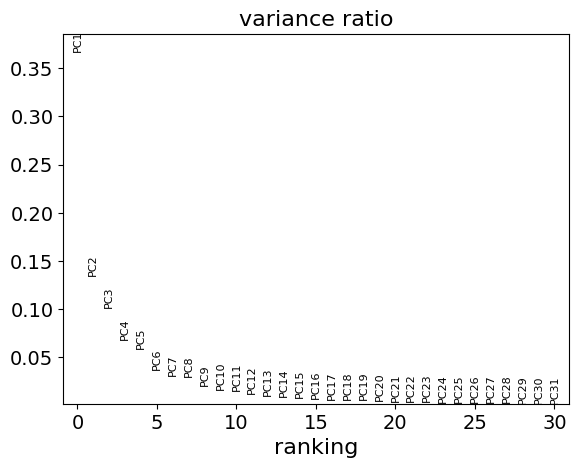

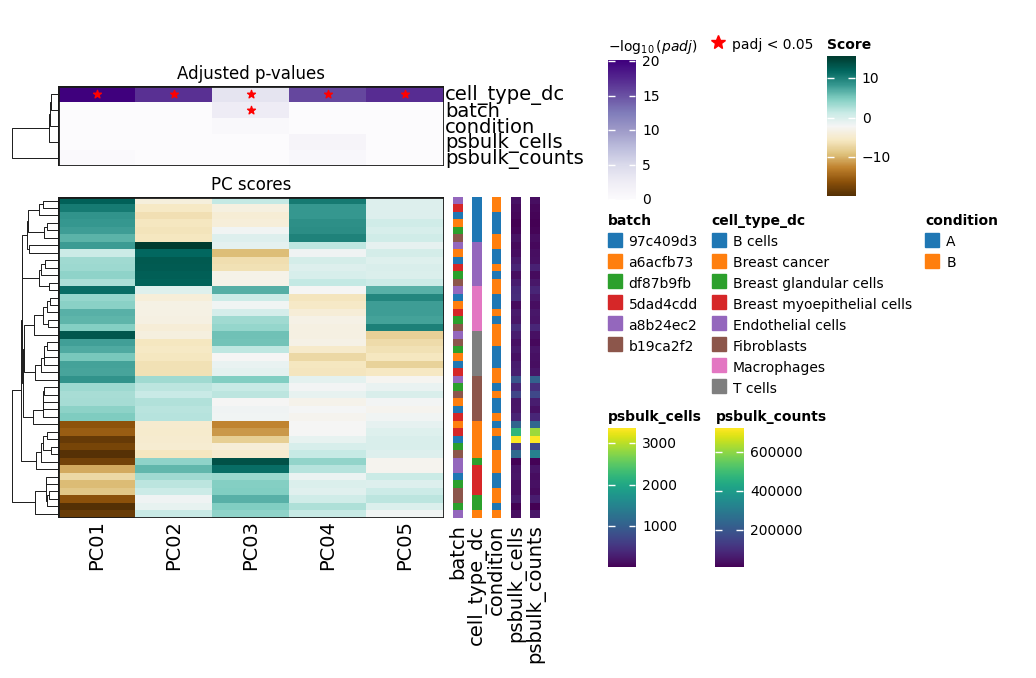

In [60]:
sc.pl.pca_variance_ratio(pdata_without_neighborhood)
dc.pl.obsm(adata=pdata_without_neighborhood, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

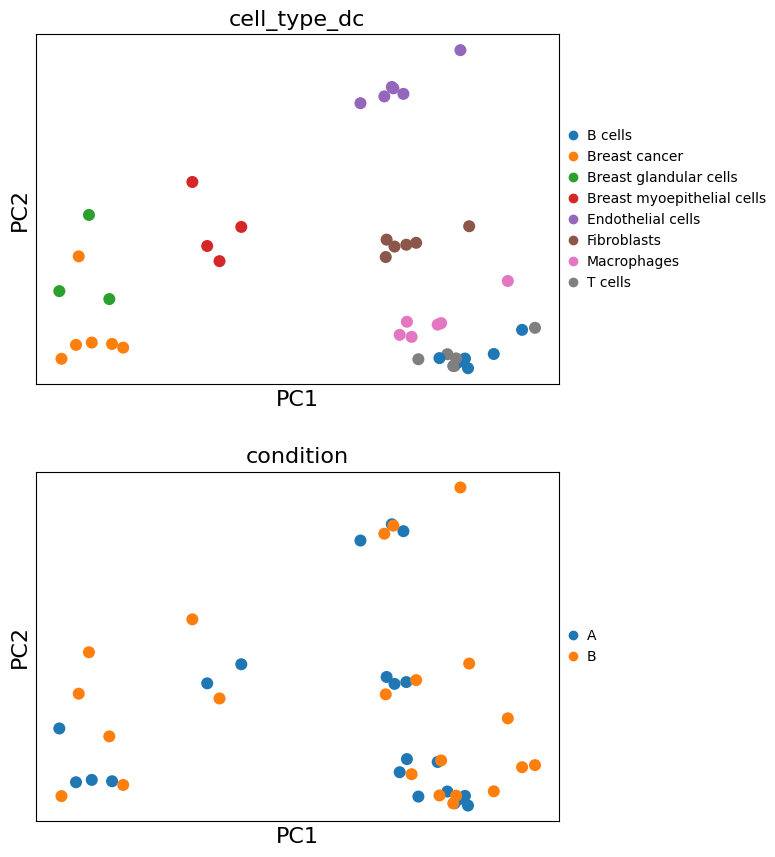

In [61]:
sc.pl.pca(
    pdata_without_neighborhood,
    color=["cell_type_dc",'condition'],
    ncols=1,
    size=300,
    frameon=True,
)

### Differential expressed genes between two conditions

In [63]:
endothelial_cells = pdata_without_neighborhood[pdata_without_neighborhood.obs["cell_type_dc"] == "Endothelial cells"].copy()
endothelial_cells

AnnData object with n_obs × n_vars = 6 × 297
    obs: 'batch', 'cell_type_dc', 'condition', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'cell_type_dc_colors', 'condition_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

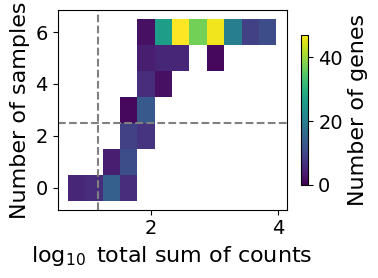

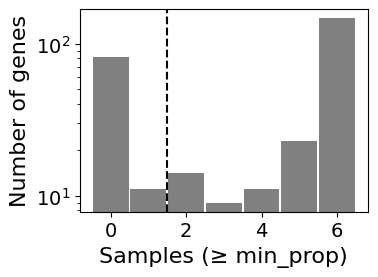

In [64]:
dc.pl.filter_by_expr(
    adata=endothelial_cells,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endothelial_cells,
    min_prop=0.1,
    min_smpls=2,
)

In [65]:
dc.pp.filter_by_expr(
    adata=endothelial_cells,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endothelial_cells,
    min_prop=0.1,
    min_smpls=2,
)
endothelial_cells

AnnData object with n_obs × n_vars = 6 × 204
    obs: 'batch', 'cell_type_dc', 'condition', 'psbulk_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'rank_obsm', 'cell_type_dc_colors', 'condition_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts', 'X'

In [66]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endothelial_cells,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["condition", "A", "B"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_58922/2498213645.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.16 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...


Log2 fold change & Wald test p-value: condition A vs B
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TCEAL7     20.580693       -0.898922  0.602207 -1.492713  0.135512  0.990982
SERPINA3  126.787130       -0.958092  0.652032 -1.469394  0.141726  0.990982
VOPP1     206.368311        0.169614  0.247680  0.684812  0.493462  0.990982
MYO5B      36.791202        0.566818  0.515752  1.099013  0.271763  0.990982
TCF4      369.884157       -0.118110  0.208739 -0.565829  0.571510  0.990982
...              ...             ...       ...       ...       ...       ...
BASP1     127.804365        0.004041  0.385312  0.010489  0.991631  0.997405
CCND1     816.785347        0.321695  0.274120  1.173552  0.240575  0.990982
PIM1       51.873209       -0.133026  0.454626 -0.292605  0.769824  0.990982
GPR183     31.301874       -0.161696  0.445352 -0.363075  0.716549  0.990982
RAB30      53.521757        0.041005  0.332024  0.123499  0.901712  0.990982

[204 rows x 6 column

... done in 0.10 seconds.

Fitting LFCs...
... done in 0.06 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.06 seconds.



In [67]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TCEAL7,20.580693,-0.898922,0.602207,-1.492713,0.135512,0.990982
SERPINA3,126.787130,-0.958092,0.652032,-1.469394,0.141726,0.990982
VOPP1,206.368311,0.169614,0.247680,0.684812,0.493462,0.990982
MYO5B,36.791202,0.566818,0.515752,1.099013,0.271763,0.990982
TCF4,369.884157,-0.118110,0.208739,-0.565829,0.571510,0.990982
...,...,...,...,...,...,...
BASP1,127.804365,0.004041,0.385312,0.010489,0.991631,0.997405
CCND1,816.785347,0.321695,0.274120,1.173552,0.240575,0.990982
PIM1,51.873209,-0.133026,0.454626,-0.292605,0.769824,0.990982
GPR183,31.301874,-0.161696,0.445352,-0.363075,0.716549,0.990982


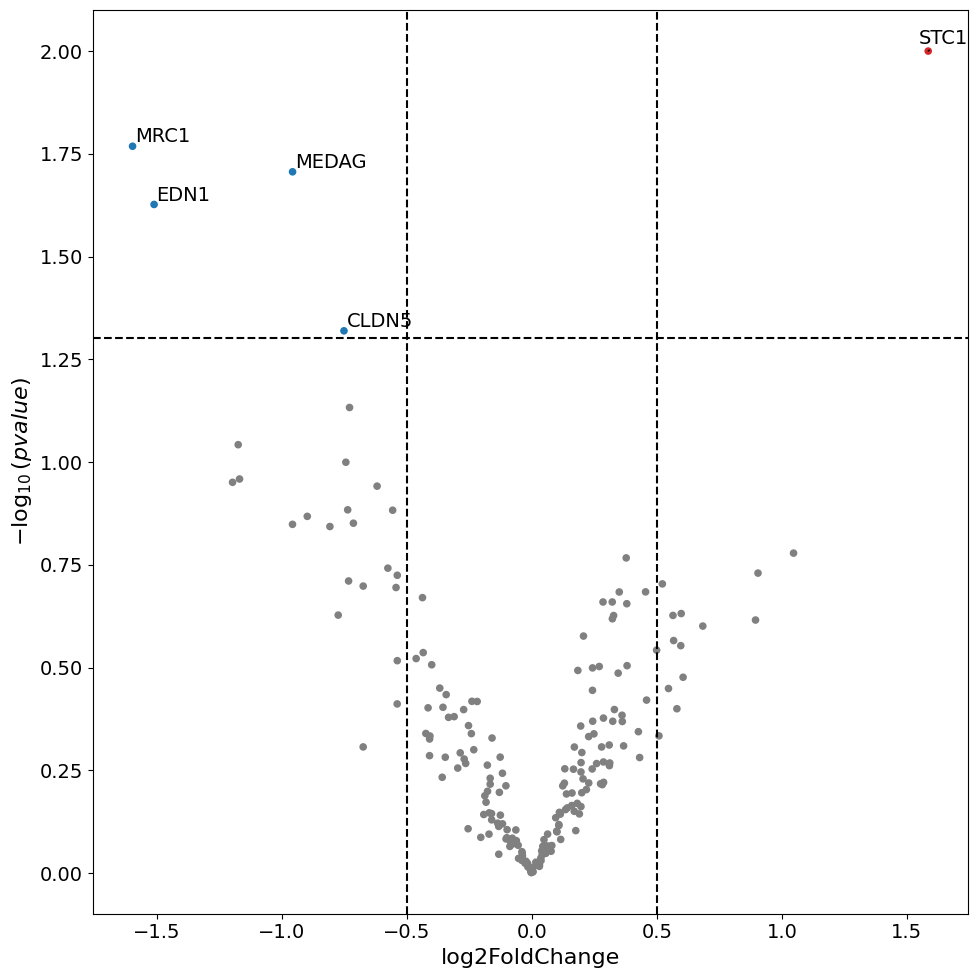

In [68]:
dc.pl.volcano(results_df, x="log2FoldChange", y="pvalue",figsize=(10,10),top=40)

In [69]:
data = results_df[["stat"]].T.rename(index={"stat": "A vs. B"})
data

,TCEAL7,SERPINA3,VOPP1,MYO5B,TCF4,DSP,PCOLCE,TRAPPC3,DUSP5,CCPG1,...,CXCL16,POSTN,HOXD9,TFAP2A,PTGDS,BASP1,CCND1,PIM1,GPR183,RAB30
A vs. B,-1.492713,-1.469394,0.684812,1.099013,-0.565829,-0.478395,0.406009,0.518528,-0.220152,-0.041757,...,-0.042702,-0.367128,0.131484,-0.248424,-1.185984,0.010489,1.173552,-0.292605,-0.363075,0.123499


### Pathway analysis

In [70]:
progeny = dc.op.progeny(organism="human")
progeny

,source,target,weight,padj
0,Androgen,TMPRSS2,11.490631,2.384806e-47
1,Androgen,NKX3-1,10.622551,2.205102e-44
2,Androgen,MBOAT2,10.472733,4.632376e-44
3,Androgen,KLK2,10.176186,1.944410e-40
4,Androgen,SARG,11.386852,2.790210e-40
...,...,...,...,...
62416,p53,ENPP2,2.771405,4.993215e-02
62417,p53,ARRDC4,3.494328,4.996747e-02
62418,p53,MYO1B,-1.148057,4.997905e-02
62419,p53,CTSC,-1.784693,4.998864e-02


In [71]:
# Run
pw_acts, pw_padj = dc.mt.ulm(data=data, net=progeny)

# Filter by sign padj
msk = (pw_padj.T < 0.05).iloc[:, 0]
pw_acts = pw_acts.loc[:, msk]

pw_acts

""
A vs. B


### Caution: In the example no significant pathways were found! (caused by fake column)

IndexError: list index out of range

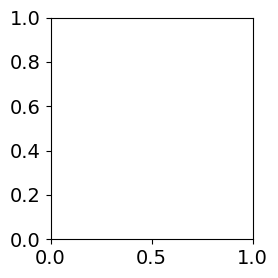

In [73]:
dc.pl.barplot(data=pw_acts, name="A vs. B", figsize=(3, 3))  

ValueError: zero-size array to reduction operation minimum which has no identity

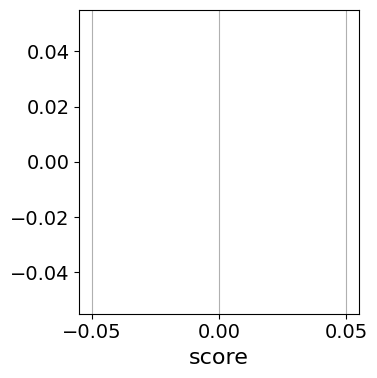

In [74]:
# Transform to df
import numpy as np

df = pw_acts.melt(value_name="score").merge(
    pw_padj.melt(value_name="pvalue")
    .assign(logpval=lambda x: x["pvalue"].clip(2.22e-4, 1))
    .assign(logpval=lambda x: -np.log10(x["logpval"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="logpval", c="score", scale=1, figsize=(4, 4))

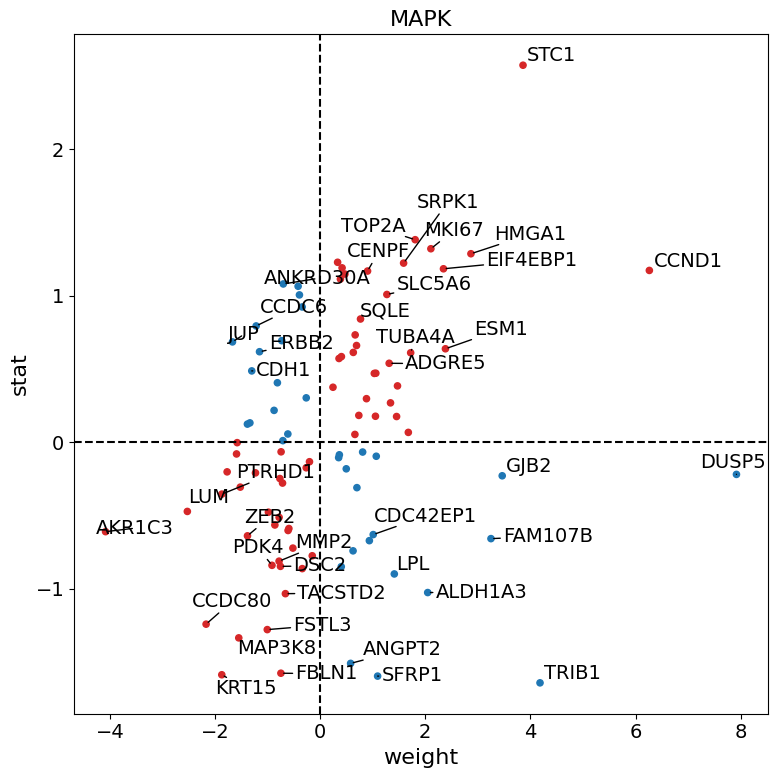

In [75]:
dc.pl.source_targets(data=results_df, x="weight", y="stat", net=progeny, name="MAPK", top=40, figsize=(8, 8))

(+) leading edge: ['STC1' 'TOP2A' 'MKI67' 'HMGA1' 'CLEC14A']
(-) leading edge: ['KRT15' 'FBLN1' 'MAP3K8' 'FSTL3' 'CCDC80']


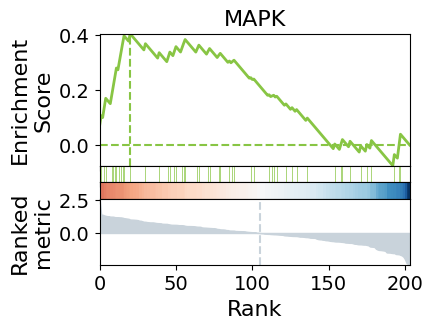

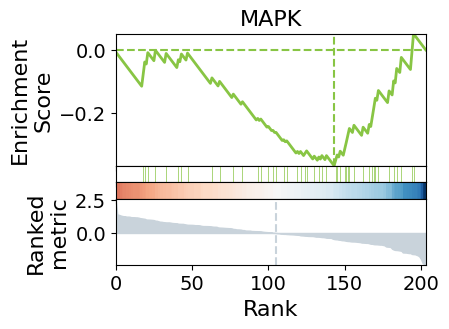

In [76]:
_, pos_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] > 0],
    name="MAPK",
)
print("(+) leading edge:", pos_le[:5])
_, neg_le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=progeny[progeny["weight"] < 0],
    name="MAPK",
)
print("(-) leading edge:", neg_le[:5])

In [77]:
hallmark = dc.op.hallmark(organism="human")
hallmark

,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF
...,...,...
7313,PANCREAS_BETA_CELLS,STXBP1
7314,PANCREAS_BETA_CELLS,ELP4
7315,PANCREAS_BETA_CELLS,GCG
7316,PANCREAS_BETA_CELLS,PCSK2


### Hallmark gene sets

In [78]:
# Run
hm_acts, hm_padj = dc.mt.ulm(data=data, net=hallmark)

# Filter by sign padj
msk = (hm_padj.T < 0.05).iloc[:, 0]
hm_acts = hm_acts.loc[:, msk]

hm_acts

,EPITHELIAL_MESENCHYMAL_TRANSITION,G2M_CHECKPOINT
A vs. B,-3.186268,3.694056


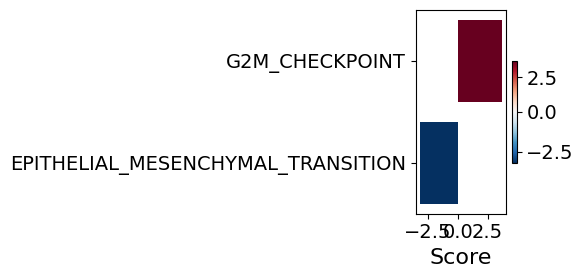

In [80]:
dc.pl.barplot(data=hm_acts, name="A vs. B", figsize=(6, 3))

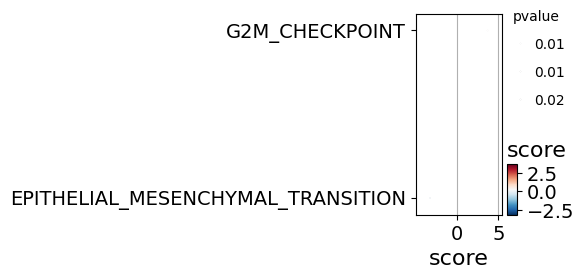

In [81]:
# Tranform to df
df = hm_acts.melt(value_name="score").merge(
    hm_padj.melt(value_name="pvalue")
    .assign(padj=lambda x: x["pvalue"].clip(2.22e-16, 1))
    .assign(padj=lambda x: np.log10(x["pvalue"]))
)
dc.pl.dotplot(df=df, x="score", y="variable", s="pvalue", c="score", scale=0.25, figsize=(6, 3))

leading edge: ['TOP2A' 'MKI67' 'HMGA1' 'CCND1' 'CENPF']


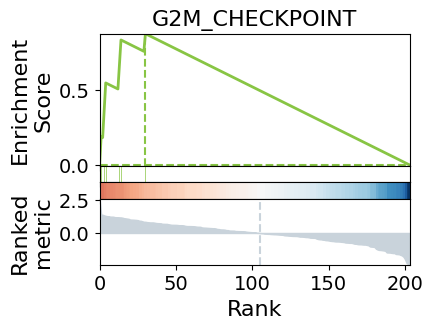

In [82]:
_, le = dc.pl.leading_edge(
    results_df,
    stat="stat",
    net=hallmark,
    name="G2M_CHECKPOINT",
)
print("leading edge:", le[:5])

### Generating pseudobulk with consideration of neighborhood

In [101]:
pdata=generate_pseudobulk(exp=exp,cell_layer='main',raw_counts='counts',sample_col='batch',groups_col='cell_type_dc',calculate_neighbors=True,radius=20)

97c409d3


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


a6acfb73


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


df87b9fb


...

/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


a8b24ec2


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


b19ca2f2


/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/opt/anaconda3/envs/insitupy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [102]:
pdata

AnnData object with n_obs × n_vars = 99 × 297
    obs: 'batch', 'condition', 'psbulk_cells', 'psbulk_counts', 'cell_type_dc', 'neighbors'
    layers: 'psbulk_props'

In [103]:
pdata.obs

,batch,condition,psbulk_cells,psbulk_counts,cell_type_dc,neighbors
97c409d3_Macrophages_neighbors,97c409d3,A,1337.0,202681.0,Macrophages,neighbors
97c409d3_Breast cancer_neighbors,97c409d3,A,4105.0,827125.0,Breast cancer,neighbors
97c409d3_Breast myoepithelial cells_neighbors,97c409d3,A,911.0,151753.0,Breast myoepithelial cells,neighbors
97c409d3_Endothelial cells_neighbors,97c409d3,A,888.0,133127.0,Endothelial cells,neighbors
97c409d3_T cells_neighbors,97c409d3,A,1021.0,152930.0,T cells,neighbors
...,...,...,...,...,...,...
b19ca2f2_Endothelial cells,b19ca2f2,B,295.0,50518.0,Endothelial cells,cell
b19ca2f2_Fibroblasts,b19ca2f2,B,727.0,163049.0,Fibroblasts,cell
b19ca2f2_Macrophages,b19ca2f2,B,449.0,83052.0,Macrophages,cell
b19ca2f2_Mast cells,b19ca2f2,B,7.0,595.0,Mast cells,cell


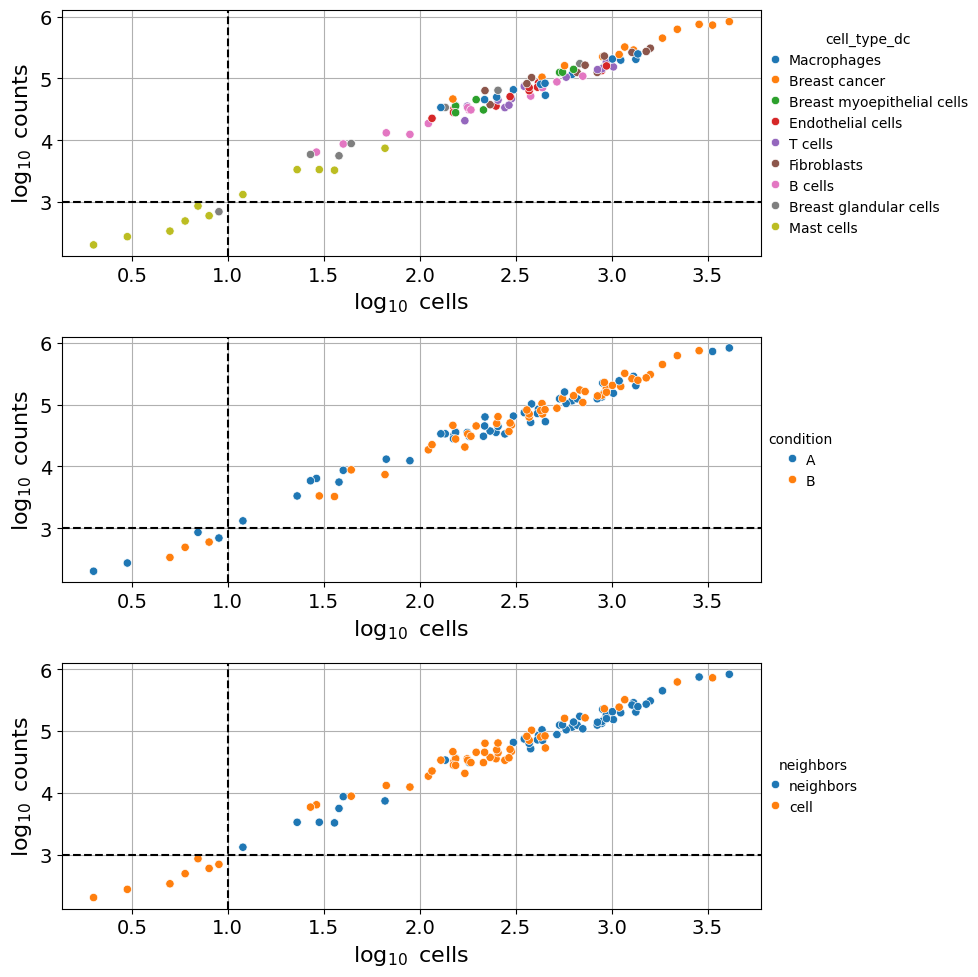

In [104]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=['cell_type_dc', "condition", "neighbors"],
    min_cells=10,
    min_counts=1000,
    figsize=(10, 10),
)

In [105]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)

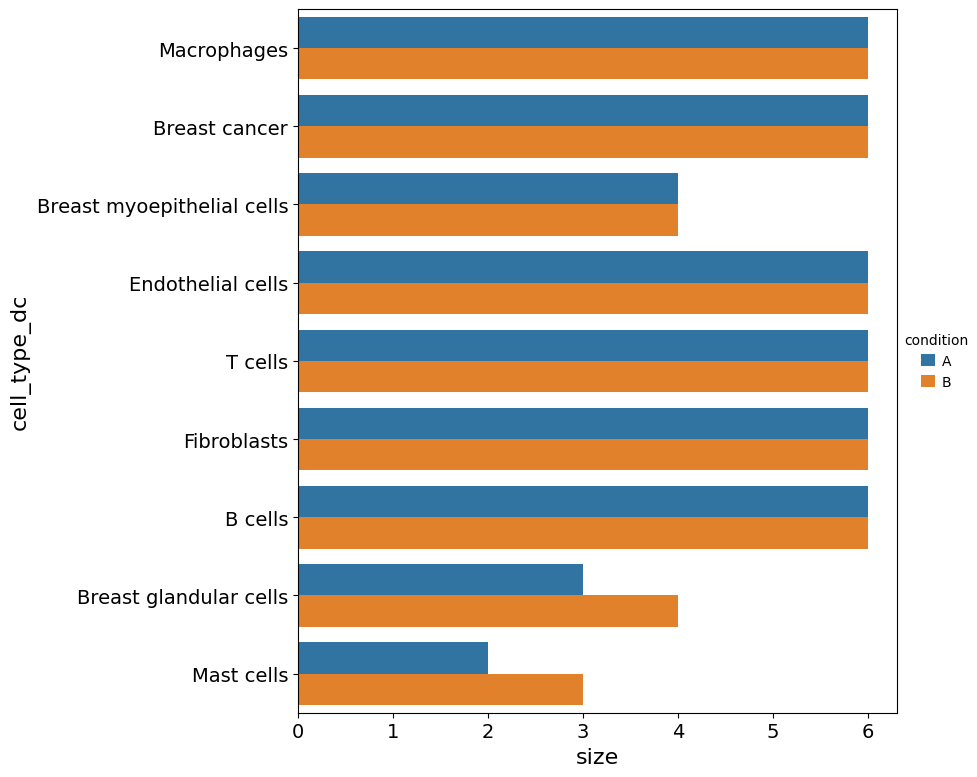

In [106]:
dc.pl.obsbar(adata=pdata, y="cell_type_dc", hue="condition", figsize=(10, 8))

In [107]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)

In [108]:
pdata.obs.columns

Index(['batch', 'condition', 'psbulk_cells', 'psbulk_counts', 'cell_type_dc',
       'neighbors'],
      dtype='object')

#### all columns in obs must have at least 2 different features

In [109]:
dc.tl.rankby_obsm(pdata, key="X_pca")

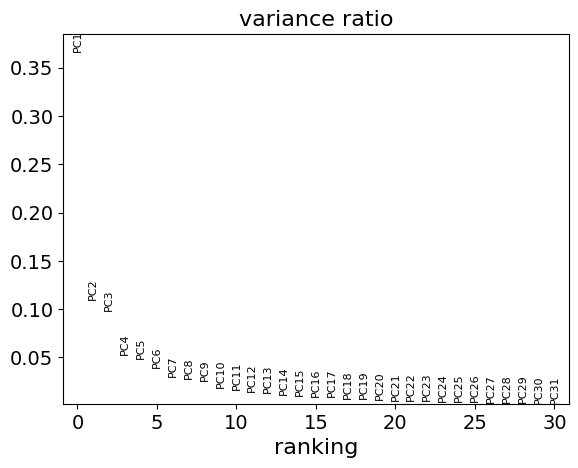

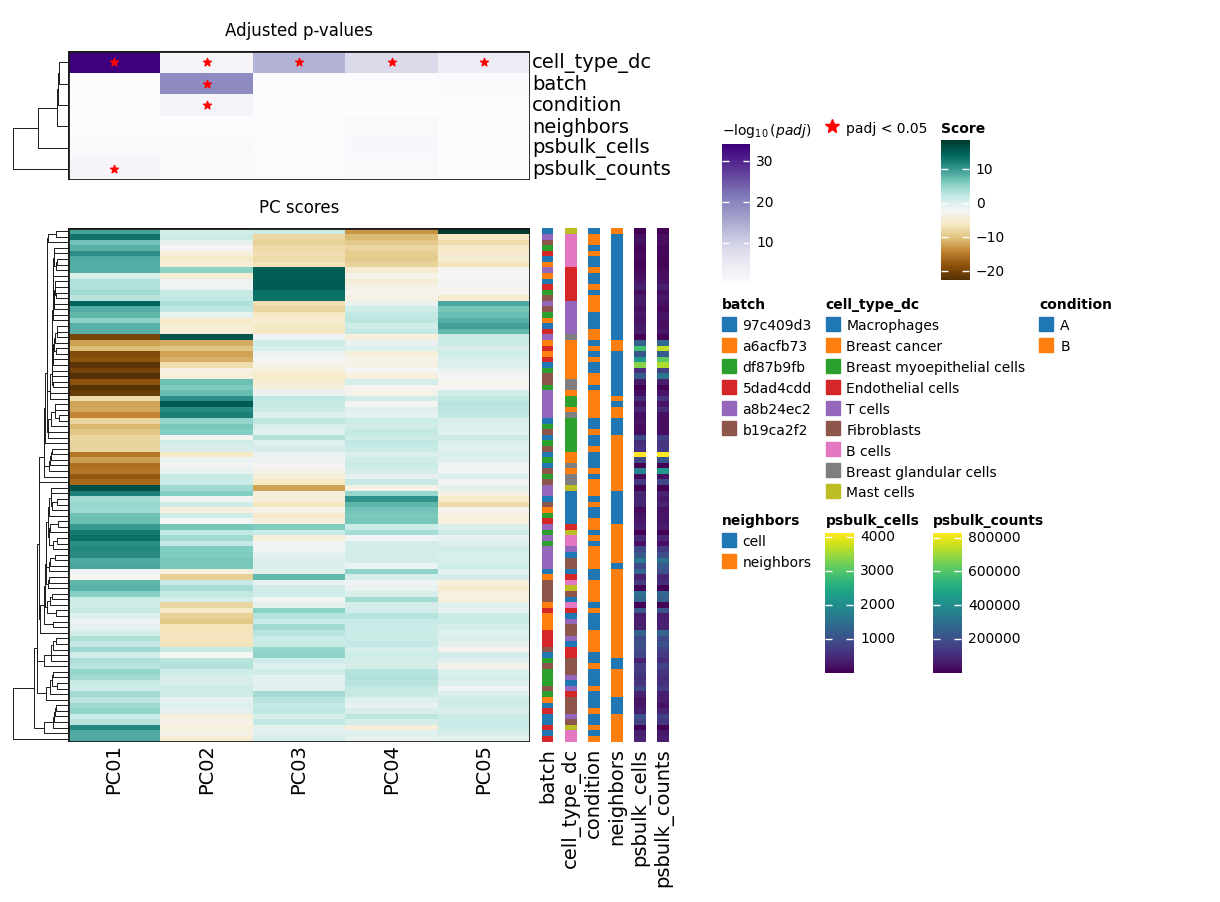

In [110]:
sc.pl.pca_variance_ratio(pdata)
dc.pl.obsm(adata=pdata, return_fig=True, nvar=5, titles=["PC scores", "Adjusted p-values"], figsize=(12, 8))

... storing 'neighbors' as categorical


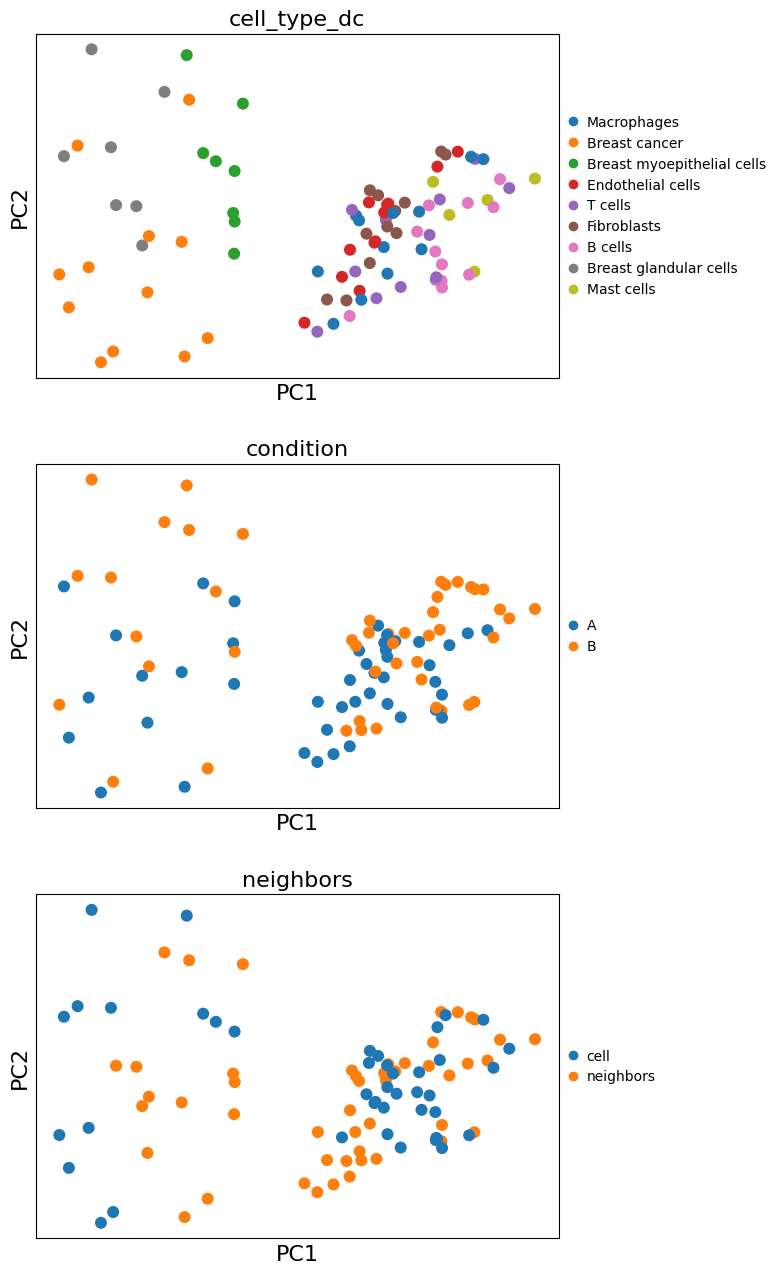

In [111]:
sc.pl.pca(
    pdata,
    color=["cell_type_dc", "condition","neighbors"],
    ncols=1,
    size=300,
    frameon=True,
)

### Differential expressed genes

In [112]:
endothelial_cells = pdata[pdata.obs['cell_type_dc'] == "Endothelial cells"].copy()
endothelial_cells.obs

,batch,condition,psbulk_cells,psbulk_counts,cell_type_dc,neighbors
97c409d3_Endothelial cells_neighbors,97c409d3,A,888.0,133127.0,Endothelial cells,neighbors
a6acfb73_Endothelial cells_neighbors,a6acfb73,A,415.0,84352.0,Endothelial cells,neighbors
df87b9fb_Endothelial cells_neighbors,df87b9fb,A,410.0,71764.0,Endothelial cells,neighbors
5dad4cdd_Endothelial cells_neighbors,5dad4cdd,B,1094.0,214727.0,Endothelial cells,neighbors
a8b24ec2_Endothelial cells_neighbors,a8b24ec2,B,371.0,63032.0,Endothelial cells,neighbors
b19ca2f2_Endothelial cells_neighbors,b19ca2f2,B,940.0,158543.0,Endothelial cells,neighbors
97c409d3_Endothelial cells,97c409d3,A,249.0,35514.0,Endothelial cells,cell
a6acfb73_Endothelial cells,a6acfb73,A,150.0,32309.0,Endothelial cells,cell
df87b9fb_Endothelial cells,df87b9fb,A,149.0,28027.0,Endothelial cells,cell
5dad4cdd_Endothelial cells,5dad4cdd,B,371.0,70687.0,Endothelial cells,cell


In [113]:
endo_cells=endothelial_cells[endothelial_cells.obs['neighbors']=='cell']

In [115]:
endo_neighbors=endothelial_cells[endothelial_cells.obs['condition']=='A']

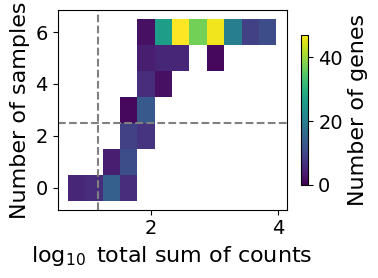

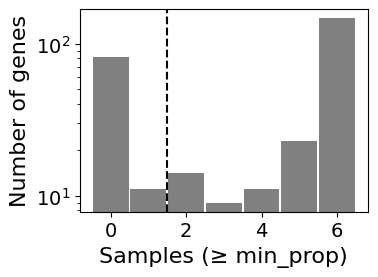

In [116]:
dc.pl.filter_by_expr(
    adata=endo_cells,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endo_cells,
    min_prop=0.1,
    min_smpls=2,
)

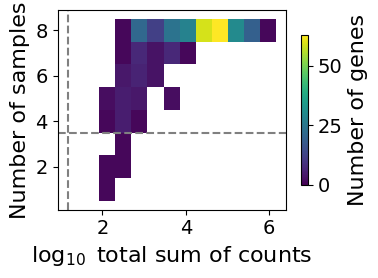

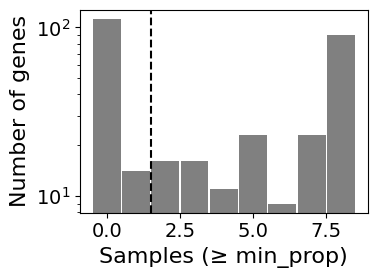

In [59]:
dc.pl.filter_by_expr(
    adata=endo_neighbors,
    group="neighbors",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=endo_neighbors,
    min_prop=0.1,
    min_smpls=2,
)

In [117]:
dc.pp.filter_by_expr(
    adata=endo_cells,
    group="condition",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endo_cells,
    min_prop=0.1,
    min_smpls=2,
)
endo_cells.obs

,batch,condition,psbulk_cells,psbulk_counts,cell_type_dc,neighbors
97c409d3_Endothelial cells,97c409d3,A,249.0,35514.0,Endothelial cells,cell
a6acfb73_Endothelial cells,a6acfb73,A,150.0,32309.0,Endothelial cells,cell
df87b9fb_Endothelial cells,df87b9fb,A,149.0,28027.0,Endothelial cells,cell
5dad4cdd_Endothelial cells,5dad4cdd,B,371.0,70687.0,Endothelial cells,cell
a8b24ec2_Endothelial cells,a8b24ec2,B,115.0,22477.0,Endothelial cells,cell
b19ca2f2_Endothelial cells,b19ca2f2,B,295.0,50518.0,Endothelial cells,cell


In [118]:
dc.pp.filter_by_expr(
    adata=endo_neighbors,
    group="neighbors",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=endo_neighbors,
    min_prop=0.1,
    min_smpls=2,
)
endo_neighbors.obs

,batch,condition,psbulk_cells,psbulk_counts,cell_type_dc,neighbors
97c409d3_Endothelial cells_neighbors,97c409d3,A,888.0,133127.0,Endothelial cells,neighbors
a6acfb73_Endothelial cells_neighbors,a6acfb73,A,415.0,84352.0,Endothelial cells,neighbors
df87b9fb_Endothelial cells_neighbors,df87b9fb,A,410.0,71764.0,Endothelial cells,neighbors
97c409d3_Endothelial cells,97c409d3,A,249.0,35514.0,Endothelial cells,cell
a6acfb73_Endothelial cells,a6acfb73,A,150.0,32309.0,Endothelial cells,cell
df87b9fb_Endothelial cells,df87b9fb,A,149.0,28027.0,Endothelial cells,cell


In [119]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endo_cells,
    design_factors=["condition"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["condition", "A", "B"], inference=inference)

# Compute Wald test
stat_res.summary()

Using None as control genes, passed at DeseqDataSet initialization


/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_58922/1597025669.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.13 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.07 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.06 seconds.



Log2 fold change & Wald test p-value: condition A vs B
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TCEAL7     20.580693       -0.898922  0.602207 -1.492713  0.135512  0.990982
SERPINA3  126.787130       -0.958092  0.652032 -1.469394  0.141726  0.990982
VOPP1     206.368311        0.169614  0.247680  0.684812  0.493462  0.990982
MYO5B      36.791202        0.566818  0.515752  1.099013  0.271763  0.990982
TCF4      369.884157       -0.118110  0.208739 -0.565829  0.571510  0.990982
...              ...             ...       ...       ...       ...       ...
BASP1     127.804365        0.004041  0.385312  0.010489  0.991631  0.997405
CCND1     816.785347        0.321695  0.274120  1.173552  0.240575  0.990982
PIM1       51.873209       -0.133026  0.454626 -0.292605  0.769824  0.990982
GPR183     31.301874       -0.161696  0.445352 -0.363075  0.716549  0.990982
RAB30      53.521757        0.041005  0.332024  0.123499  0.901712  0.990982

[204 rows x 6 column

In [120]:
# Extract results
results_df_endo = stat_res.results_df
results_df_endo

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TCEAL7,20.580693,-0.898922,0.602207,-1.492713,0.135512,0.990982
SERPINA3,126.787130,-0.958092,0.652032,-1.469394,0.141726,0.990982
VOPP1,206.368311,0.169614,0.247680,0.684812,0.493462,0.990982
MYO5B,36.791202,0.566818,0.515752,1.099013,0.271763,0.990982
TCF4,369.884157,-0.118110,0.208739,-0.565829,0.571510,0.990982
...,...,...,...,...,...,...
BASP1,127.804365,0.004041,0.385312,0.010489,0.991631,0.997405
CCND1,816.785347,0.321695,0.274120,1.173552,0.240575,0.990982
PIM1,51.873209,-0.133026,0.454626,-0.292605,0.769824,0.990982
GPR183,31.301874,-0.161696,0.445352,-0.363075,0.716549,0.990982


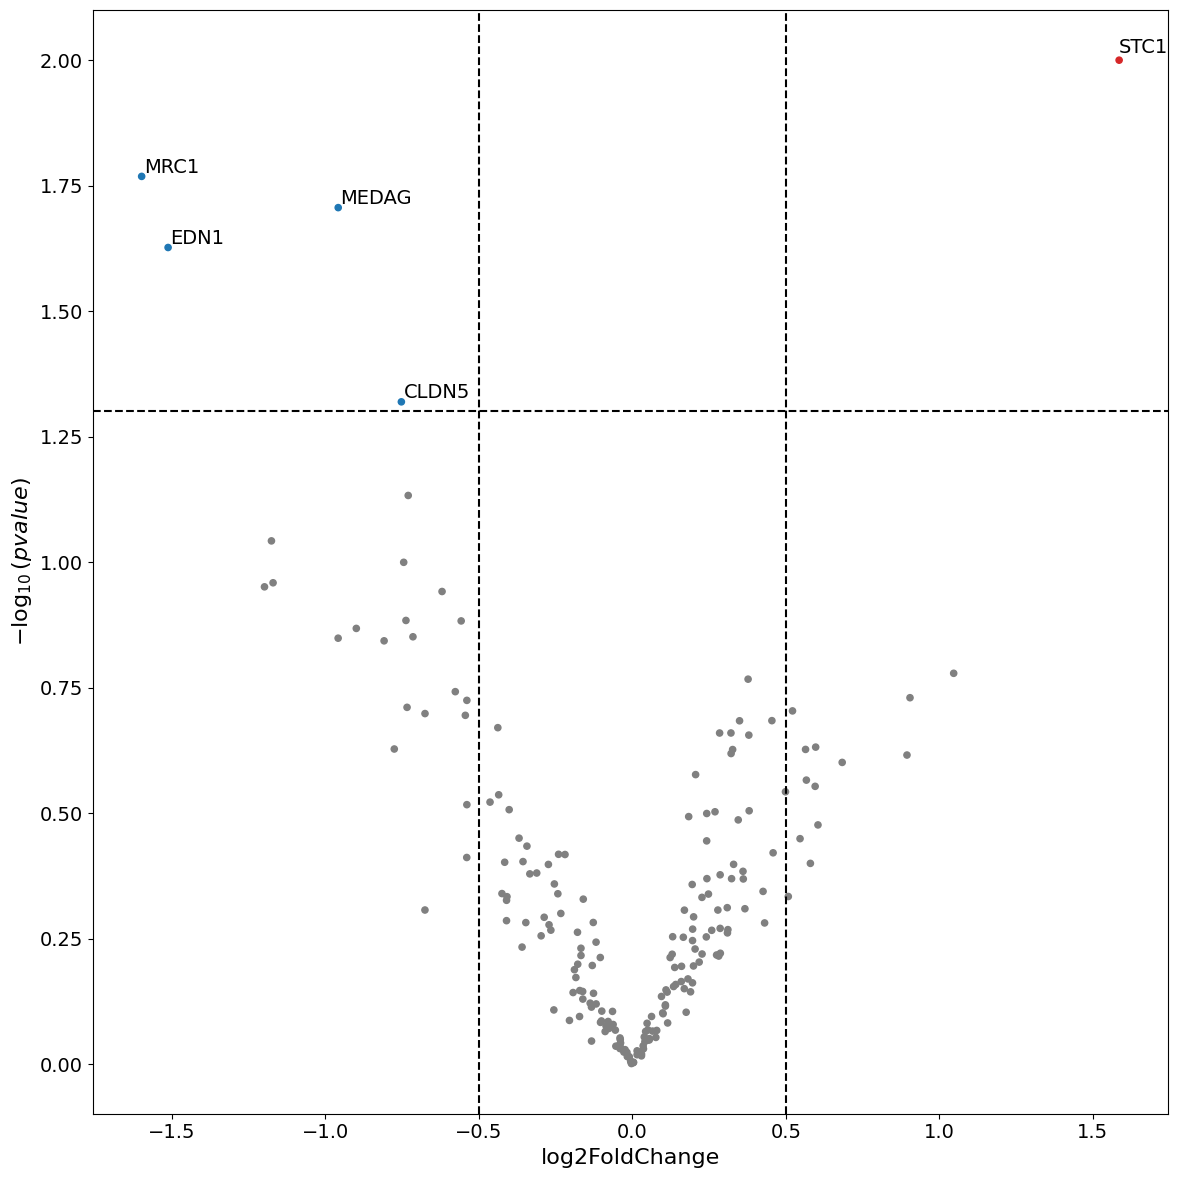

In [121]:
dc.pl.volcano(results_df_endo, x="log2FoldChange", y="pvalue",figsize=(12,12),top=40)

In [122]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=endo_neighbors,
    design_factors=["neighbors"],
    refit_cooks=True,
    inference=inference,
)

# Compute LFCs
dds.deseq2()

# Extract contrast between conditions
stat_res = DeseqStats(dds, contrast=["neighbors", "cell", "neighbors"], inference=inference)

# Compute Wald test
stat_res.summary()

/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_58922/2334804966.py:7: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.13 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: neighbors cell vs neighbors
             baseMean  log2FoldChange     lfcSE      stat        pvalue  \
SERPINA3   210.780988       -1.125423  0.802678 -1.402085  1.608900e-01   
VOPP1      315.678725        0.190385  0.257944  0.738086  4.604622e-01   
SLAMF7      50.950055       -1.528405  0.871100 -1.754570  7.933291e-02   
MYO5B      130.556517       -1.490679  0.506433 -2.943489  3.245356e-03   
TCF4       379.603779        1.342176  0.220508  6.086748  1.152270e-09   
...               ...             ...       ...       ...           ...   
BASP1      205.110368       -0.124275  0.409287 -0.303638  7.614041e-01   
CCND1     1389.320998        0.014746  0.336198  0.043860  9.650163e-01   
PIM1        69.107107        0.259165  0.446473  0.580471  5.615969e-01   
GPR183      69.219714       -1.031188  0.538259 -1.915785  5.539251e-02   
RAB30       72.494186        0.451736  0.344574  1.310996  1.898592e-01   

                  padj  
SERPINA3

... done in 0.09 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.10 seconds.



In [123]:
# Extract results
results_df_neighbors = stat_res.results_df
results_df_neighbors

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SERPINA3,210.780988,-1.125423,0.802678,-1.402085,1.608900e-01,2.846515e-01
VOPP1,315.678725,0.190385,0.257944,0.738086,4.604622e-01,6.229783e-01
SLAMF7,50.950055,-1.528405,0.871100,-1.754570,7.933291e-02,1.594360e-01
MYO5B,130.556517,-1.490679,0.506433,-2.943489,3.245356e-03,1.317233e-02
TCF4,379.603779,1.342176,0.220508,6.086748,1.152270e-09,4.770396e-08
...,...,...,...,...,...,...
BASP1,205.110368,-0.124275,0.409287,-0.303638,7.614041e-01,8.612603e-01
CCND1,1389.320998,0.014746,0.336198,0.043860,9.650163e-01,9.792077e-01
PIM1,69.107107,0.259165,0.446473,0.580471,5.615969e-01,7.220532e-01
GPR183,69.219714,-1.031188,0.538259,-1.915785,5.539251e-02,1.246331e-01


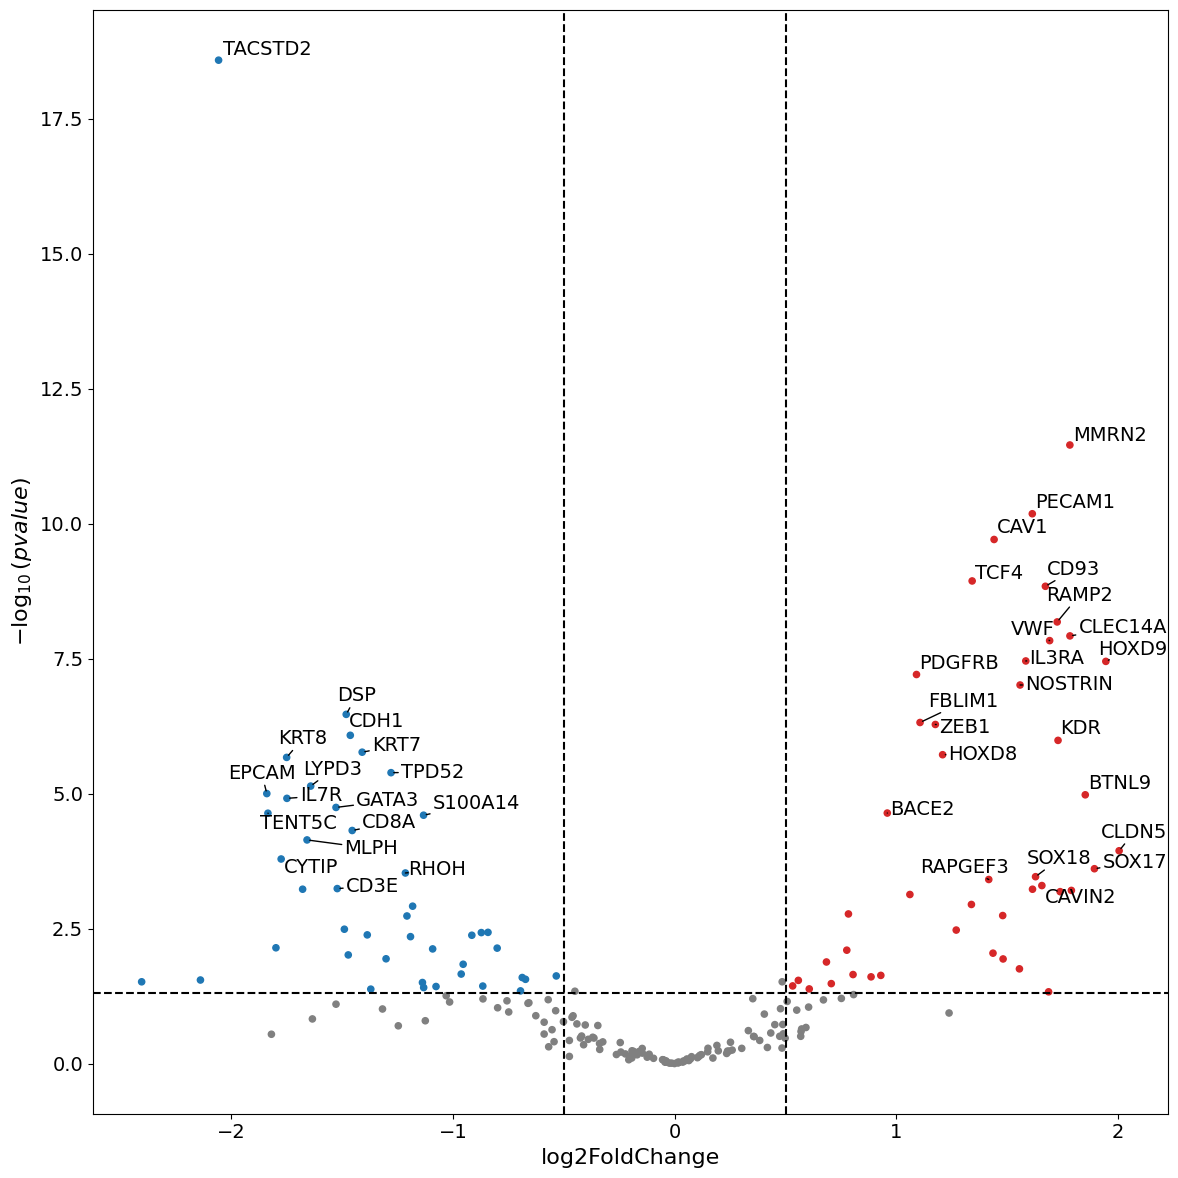

In [124]:
dc.pl.volcano(results_df_neighbors, x="log2FoldChange", y="pvalue",figsize=(12,12),top=40)

### Differential expressed genes with Consideration of gene expression in neighboring cells of target dataset

In [125]:
from insitupy.tools import two_sides_volcano

['TOP2A', 'STC1']


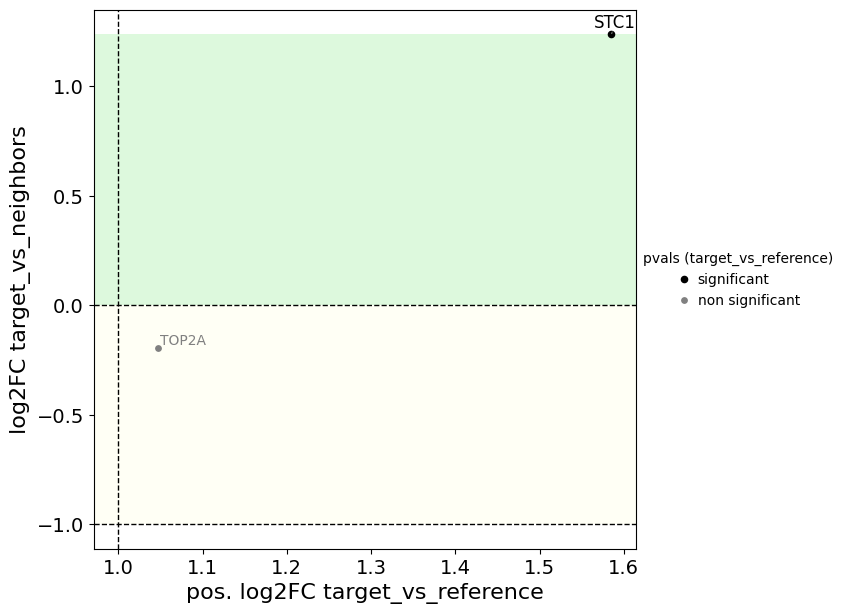

,gene,log2FoldChange_target_vs_reference,pvalue,log2FoldChange_target_vs_neighbors,neg_log10_pvals
0,TOP2A,1.046595,0.166498,-0.193782,0.778591
1,STC1,1.585409,0.009998,1.237953,2.000079


In [126]:
two_sides_volcano(results_df_normal=results_df_endo,results_df_neighbors=results_df_neighbors,significance_threshold=0.05,fold_change_threshold=1.0)